In [51]:
!pip install yfinance openpyxl -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import datetime
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After mounting your drive, you can load the file by providing the full path to the file in your Drive. For example, if your file is in the root of your Drive, the path would be `/content/drive/My Drive/processed_dataset.xlsx`.

In [53]:
# Replace '/content/drive/My Drive/processed_dataset.xlsx' with the actual path to your file
df = pd.read_excel('/content/drive/MyDrive/processed_dataset.xlsx', sheet_name='Sheet1')

In [54]:
# Convert Excel serial to datetime
def serial_to_date(serial):
    if isinstance(serial, (int, float)):
        return datetime.datetime(1899, 12, 30) + timedelta(days=serial)
    return pd.to_datetime(serial)

df['Date'] = df['Date'].apply(serial_to_date)
df['Date'] = pd.to_datetime(df['Date'])

In [55]:
# Compute Min/Max for scaling from historical data
min_open = df['Open'].min()
max_open = df['Open'].max()
min_high = df['High'].min()
max_high = df['High'].max()
min_low = df['Low'].min()
max_low = df['Low'].max()
min_close = df['Adj Close**'].min()
max_close = df['Adj Close**'].max()
min_vol = df['Volume'].min()
max_vol = df['Volume'].max()

print(f"Historical data range: {df['Date'].min()} to {df['Date'].max()}")

Historical data range: 2018-06-12 00:00:00 to 2023-04-28 00:00:00


In [56]:
# Step 2: Fetch Latest Data from Yahoo Finance (^DJI for Dow Jones)
max_historical_date = df['Date'].max()
start_date = (max_historical_date + timedelta(days=1)).strftime('%Y-%m-%d')
end_date = datetime.datetime.now().strftime('%Y-%m-%d')

print(f"Fetching new data from {start_date} to {end_date}...")
new_data = yf.download('^DJI', start=start_date, end=end_date, progress=False)

if not new_data.empty:
    new_data.reset_index(inplace=True)
    new_data.rename(columns={'Adj Close': 'Adj Close**', 'Close': 'Close*'}, inplace=True)
    new_data['Date'] = pd.to_datetime(new_data['Date'])
    print(f"Fetched {len(new_data)} new rows.")
else:
    print("No new data fetched. Using historical only.")
    new_data = pd.DataFrame()

Fetching new data from 2023-04-29 to 2025-10-19...
Fetched 620 new rows.


In [57]:
# Step 3: Combine Historical and New Data, Calculate Features
if not new_data.empty:
    # Ensure new_data has all required columns and rename them before concatenation
    if 'Close' in new_data.columns:
        new_data.rename(columns={'Close': 'Close*'}, inplace=True)
    if 'Adj Close' in new_data.columns:
        new_data.rename(columns={'Adj Close': 'Adj Close**'}, inplace=True)

    # Drop the 'Ticker' level from the columns if it exists (due to yfinance MultiIndex)
    if isinstance(new_data.columns, pd.MultiIndex):
        new_data.columns = new_data.columns.droplevel(0)

    # Select columns that exist in historical data
    hist_cols = ['Date', 'Open', 'High', 'Low', 'Adj Close**', 'Volume']
    if 'Close*' in df.columns:
        hist_cols.insert(4, 'Close*')

    # Ensure new_data only contains columns present in hist_cols to avoid errors during concatenation
    # Check if the columns in hist_cols are present in new_data after dropping the multiindex
    new_data_cols_after_droplevel = new_data.columns.tolist()
    cols_to_select = [col for col in hist_cols if col in new_data_cols_after_droplevel]

    new_data_filtered = new_data[cols_to_select]

    combined = pd.concat([df[hist_cols], new_data_filtered], ignore_index=True)
else:
    hist_cols = ['Date', 'Open', 'High', 'Low', 'Adj Close**', 'Volume']
    if 'Close*' in df.columns:
        hist_cols.insert(4, 'Close*')
    combined = df[hist_cols].copy()

# Ensure Close* column exists (use Adj Close** if not)
if 'Close*' not in combined.columns:
    combined['Close*'] = combined['Adj Close**']

# Calculate engineered features
combined['ret_1d'] = combined['Adj Close**'].pct_change()
combined['ma_7'] = combined['Adj Close**'].rolling(window=7).mean()
combined['ma_30'] = combined['Adj Close**'].rolling(window=30).mean()
combined['vol_14'] = combined['ret_1d'].rolling(window=14).std()

# Scale using historical min/max
def scale_value(x, min_val, max_val):
    if max_val == min_val:
        return 0
    return (x - min_val) / (max_val - min_val)

combined['Open_scaled'] = combined['Open'].apply(lambda x: scale_value(x, min_open, max_open))
combined['High_scaled'] = combined['High'].apply(lambda x: scale_value(x, min_high, max_high))
combined['Low_scaled'] = combined['Low'].apply(lambda x: scale_value(x, min_low, max_low))
combined['Close*_scaled'] = combined['Close*'].apply(lambda x: scale_value(x, min_close, max_close))
combined['Adj Close**_scaled'] = combined['Adj Close**'].apply(lambda x: scale_value(x, min_close, max_close))
combined['Volume_scaled'] = combined['Volume'].apply(lambda x: scale_value(x, min_vol, max_vol))

# Drop NaNs (from rolling calculations)
combined = combined.dropna().reset_index(drop=True)
print(f"Total combined data points: {len(combined)}")

Total combined data points: 1145


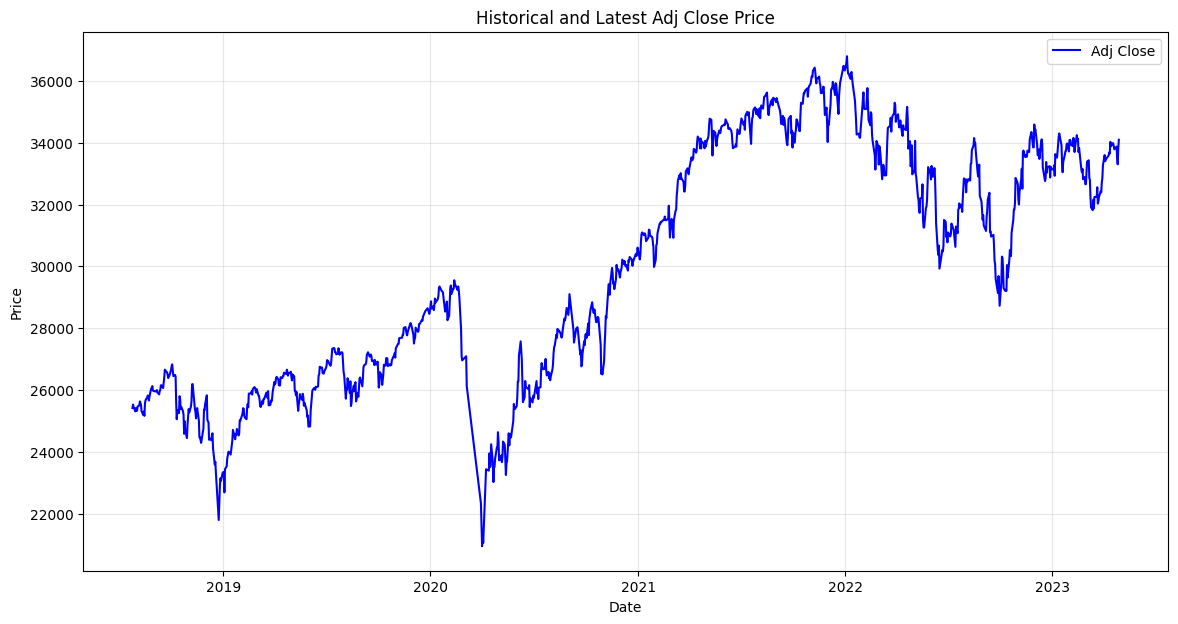

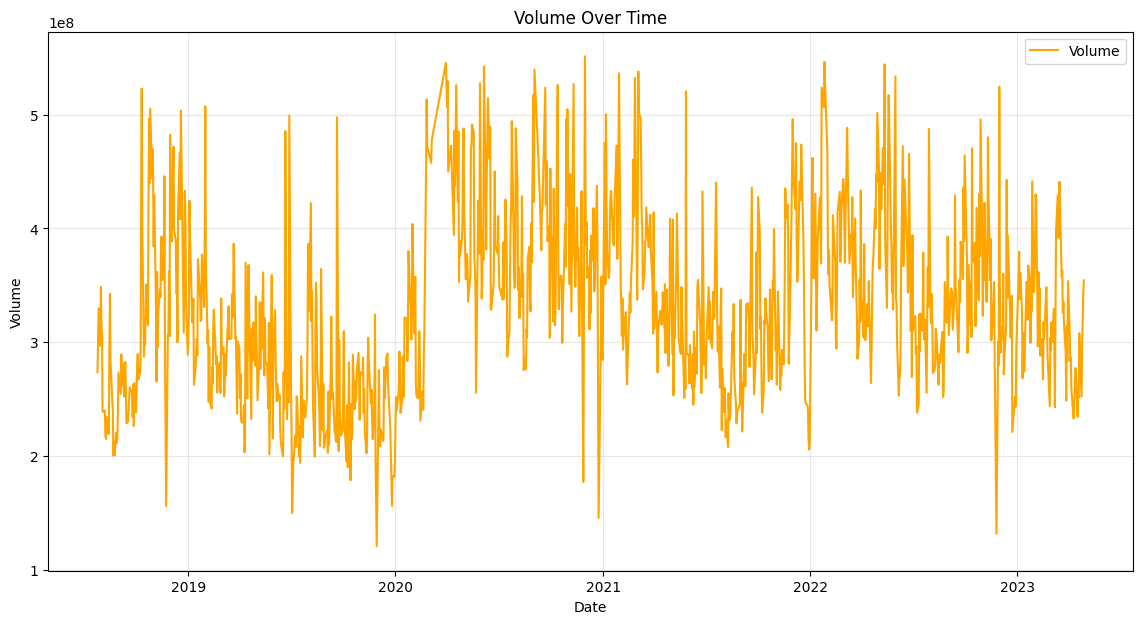

In [58]:
# Step 4: Data Visualization
plt.figure(figsize=(14, 7))
plt.plot(combined['Date'], combined['Adj Close**'], label='Adj Close', color='blue')
plt.title('Historical and Latest Adj Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(combined['Date'], combined['Volume'], label='Volume', color='orange')
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
# Step 5: Prepare Sequences for LSTM
TIME_STEP = 30
features = ['Open_scaled', 'High_scaled', 'Low_scaled', 'Close*_scaled',
            'Adj Close**_scaled', 'Volume_scaled', 'ret_1d', 'ma_7', 'ma_30', 'vol_14']

X = []
y = []
dates_for_seq = []

for i in range(len(combined) - TIME_STEP):
    X.append(combined[features].iloc[i:i+TIME_STEP].values)
    y.append(combined[['Open_scaled', 'Adj Close**_scaled']].iloc[i+TIME_STEP].values)
    dates_for_seq.append(combined['Date'].iloc[i+TIME_STEP])

X = np.array(X)
y = np.array(y)
dates_for_seq = np.array(dates_for_seq)

print(f"Total sequences: {len(X)}")

# Train-test split (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_dates = dates_for_seq[split:]

print(f"Training sequences: {len(X_train)}, Test sequences: {len(X_test)}")

# Convert to tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

# Dataset and Loader
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train_t, y_train_t)
test_dataset = StockDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Total sequences: 1115
Training sequences: 892, Test sequences: 223
Using device: cpu


In [60]:
# Step 6: LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_size=10, hidden_size=50, num_layers=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

# Training Function
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_loss = float('inf')
    early_stop_count = 0
    losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                output = model(X_batch)
                val_loss += criterion(output, y_batch).item()
        val_loss /= len(val_loader)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

        if val_loss < best_loss:
            best_loss = val_loss
            early_stop_count = 0
        else:
            early_stop_count += 1

        if early_stop_count >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return losses


Training Variety 1 (Base)
Epoch 10/50, Train Loss: 0.073694, Val Loss: 0.036676
Early stopping at epoch 12


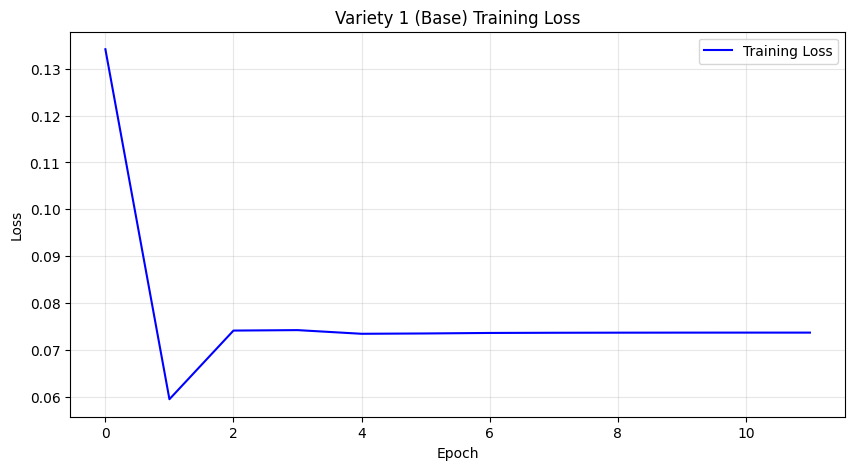


Variety 1 (Base) Metrics:
MAE Open: 2767.29, RMSE Open: 3045.22
MAE Close: 2746.09, RMSE Close: 3026.91
Accuracy: 0.4798, F1: 0.0938, Precision: 0.5000, Recall: 0.0517
Confusion Matrix:
[[101   6]
 [110   6]]


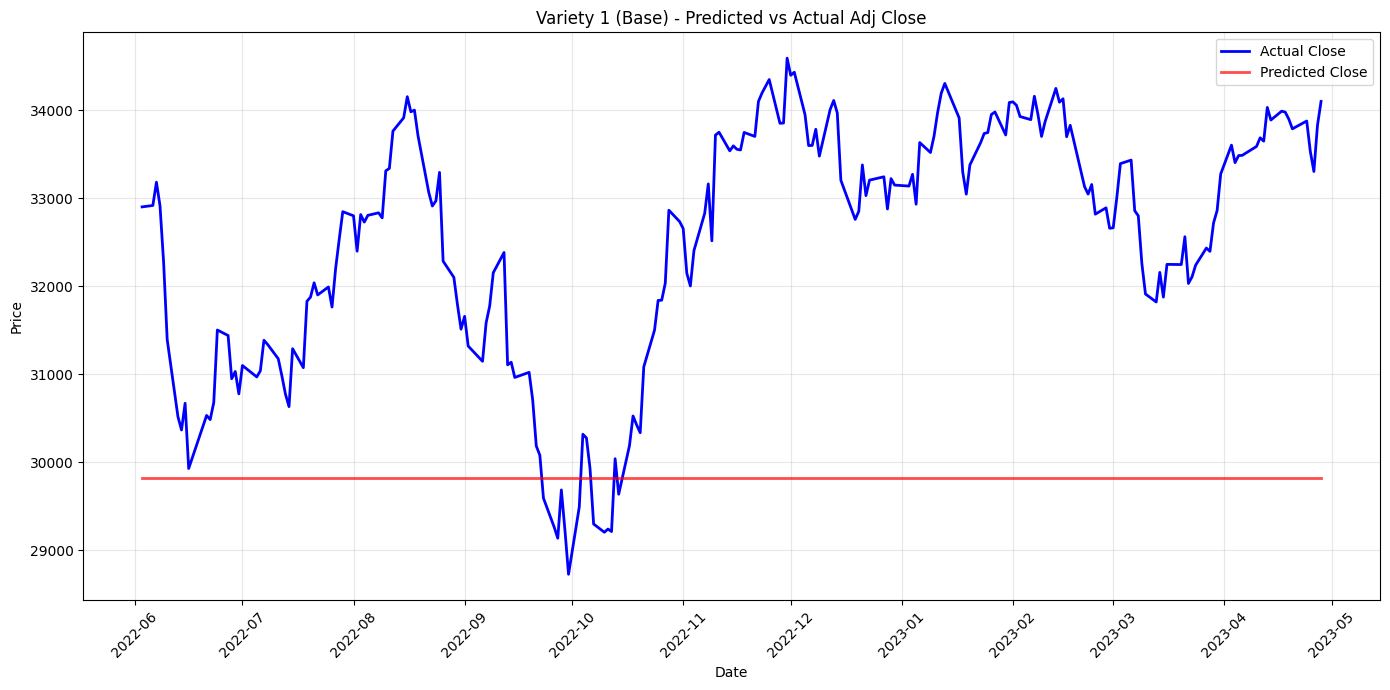


Training Variety 2 (Deeper)
Epoch 10/50, Train Loss: 0.079406, Val Loss: 0.030896
Early stopping at epoch 13


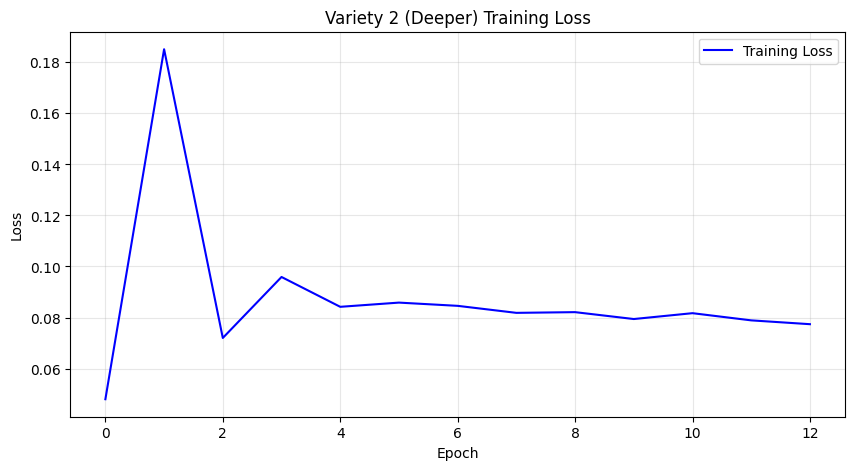


Variety 2 (Deeper) Metrics:
MAE Open: 2538.99, RMSE Open: 2819.10
MAE Close: 2574.49, RMSE Close: 2855.80
Accuracy: 0.4798, F1: 0.1077, Precision: 0.5000, Recall: 0.0603
Confusion Matrix:
[[100   7]
 [109   7]]


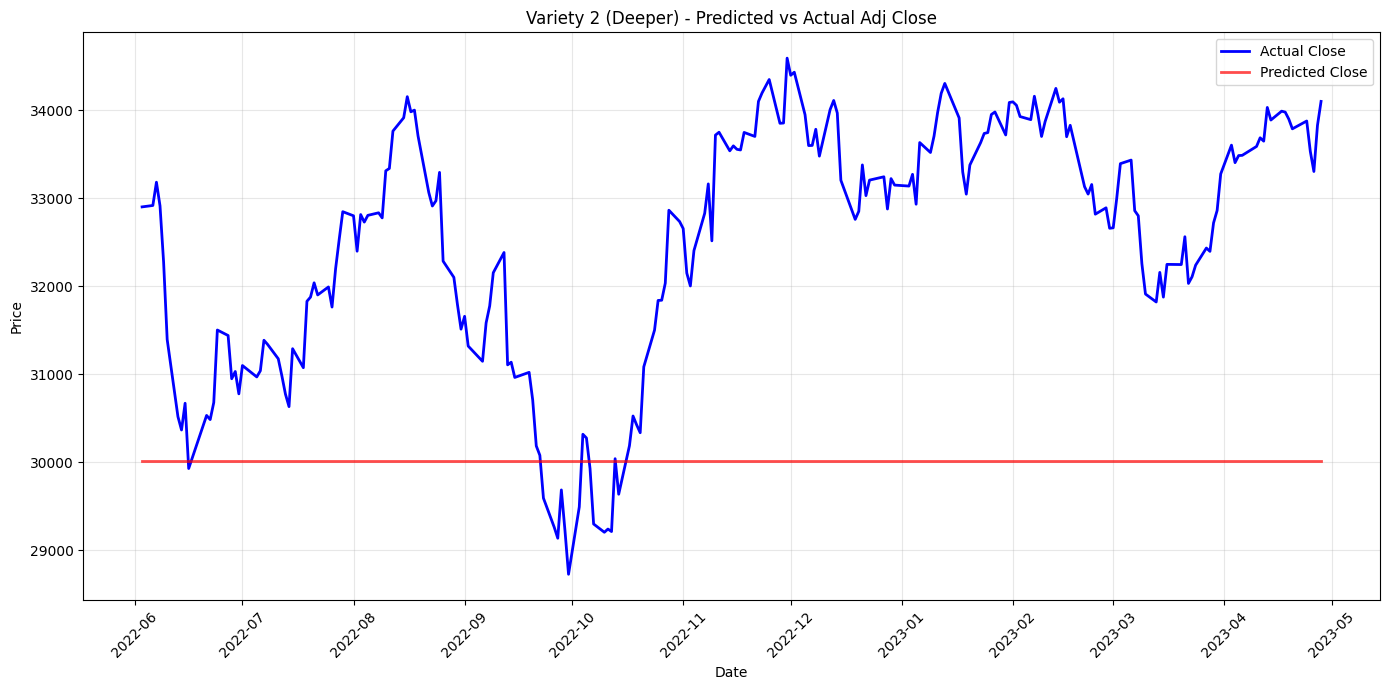


Training Variety 3 (Higher Hidden)
Epoch 10/50, Train Loss: 0.078656, Val Loss: 0.034910
Early stopping at epoch 12


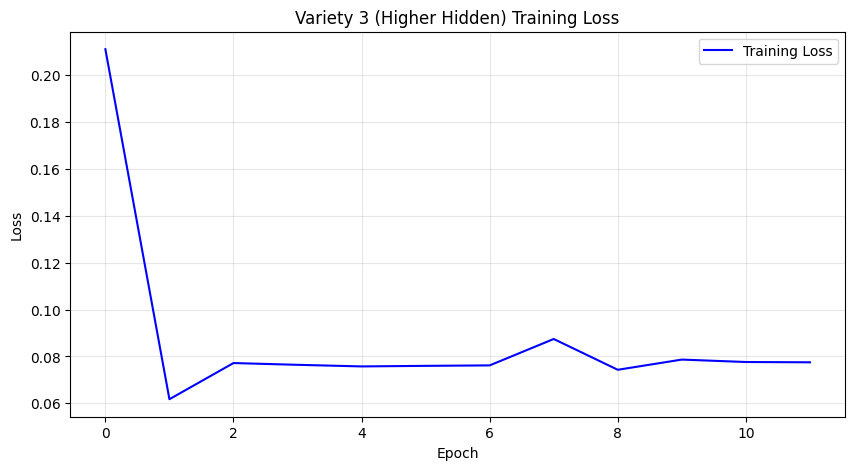


Variety 3 (Higher Hidden) Metrics:
MAE Open: 2671.59, RMSE Open: 2950.36
MAE Close: 2699.41, RMSE Close: 2980.51
Accuracy: 0.4798, F1: 0.0938, Precision: 0.5000, Recall: 0.0517
Confusion Matrix:
[[101   6]
 [110   6]]


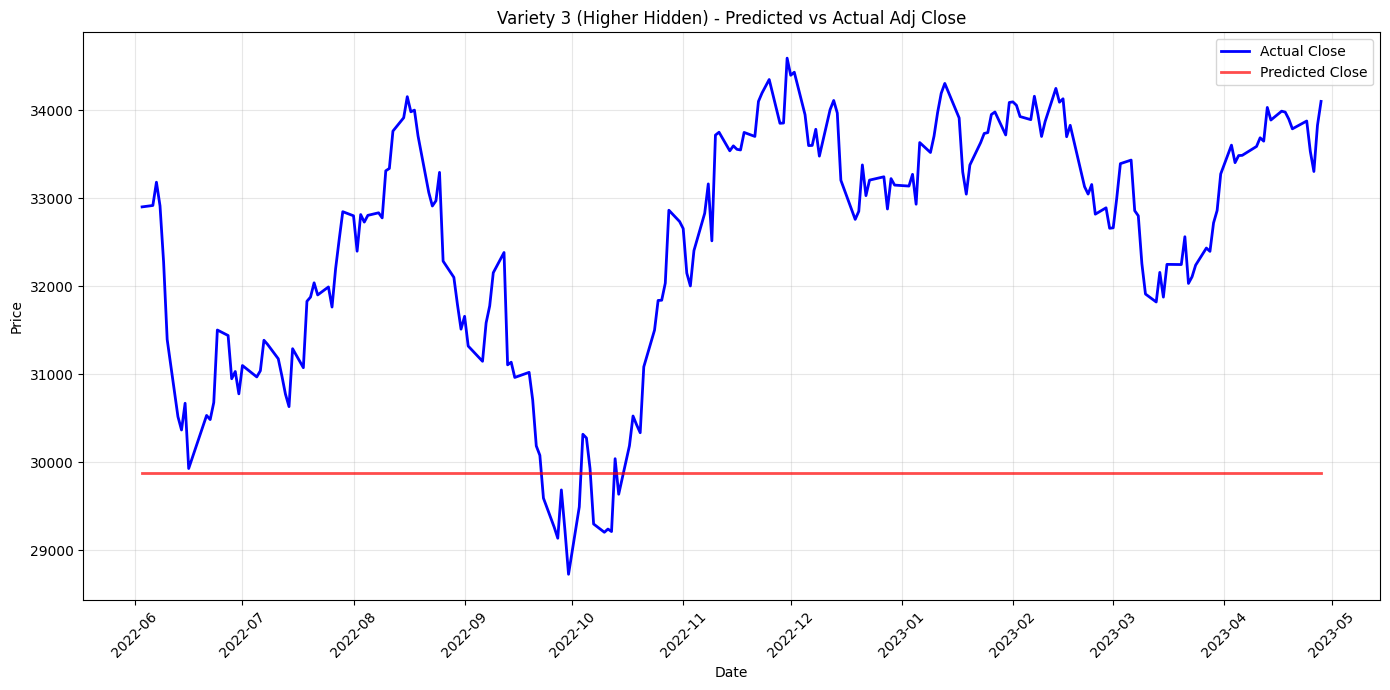

In [61]:
# Step 7: Train and Evaluate 3 Varieties
varieties = [
    {"name": "Variety 1 (Base)", "hidden_size": 50, "num_layers": 1, "dropout": 0.2, "lr": 0.001},
    {"name": "Variety 2 (Deeper)", "hidden_size": 100, "num_layers": 2, "dropout": 0.3, "lr": 0.0005},
    {"name": "Variety 3 (Higher Hidden)", "hidden_size": 100, "num_layers": 1, "dropout": 0.1, "lr": 0.001},
]

best_model = None
best_mae = float('inf')
results = {}

for var in varieties:
    print(f"\n{'='*60}")
    print(f"Training {var['name']}")
    print('='*60)

    model = LSTMModel(input_size=10, hidden_size=var["hidden_size"],
                     num_layers=var["num_layers"], dropout=var["dropout"]).to(device)
    losses = train_model(model, train_loader, test_loader, lr=var["lr"], epochs=50)

    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Training Loss', color='blue')
    plt.title(f"{var['name']} Training Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Evaluate on test
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            y_pred.extend(output.cpu().numpy())
            y_true.extend(y_batch.cpu().numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    # Denormalize
    pred_open = y_pred[:, 0] * (max_open - min_open) + min_open
    true_open = y_true[:, 0] * (max_open - min_open) + min_open
    pred_close = y_pred[:, 1] * (max_close - min_close) + min_close
    true_close = y_true[:, 1] * (max_close - min_close) + min_close

    # Regression metrics
    mae_open = mean_absolute_error(true_open, pred_open)
    mse_open = mean_squared_error(true_open, pred_open)
    rmse_open = np.sqrt(mse_open)
    mae_close = mean_absolute_error(true_close, pred_close)
    mse_close = mean_squared_error(true_close, pred_close)
    rmse_close = np.sqrt(mse_close)

    # Derived up/down classification
    prev_close = X_test[:, -1, 4] * (max_close - min_close) + min_close
    pred_up = (pred_close > prev_close).astype(int)
    true_up = (true_close > prev_close).astype(int)

    acc = accuracy_score(true_up, pred_up)
    f1 = f1_score(true_up, pred_up, zero_division=0)
    prec = precision_score(true_up, pred_up, zero_division=0)
    rec = recall_score(true_up, pred_up, zero_division=0)

    try:
        auc = roc_auc_score(true_up, pred_up)
    except:
        auc = 0.0

    cm = confusion_matrix(true_up, pred_up)

    results[var['name']] = {
        'MAE Open': mae_open, 'MAE Close': mae_close,
        'RMSE Open': rmse_open, 'RMSE Close': rmse_close,
        'Accuracy (Up/Down)': acc, 'F1': f1, 'Precision': prec, 'Recall': rec,
        'AUC': auc, 'Confusion Matrix': cm
    }

    print(f"\n{var['name']} Metrics:")
    print(f"MAE Open: {mae_open:.2f}, RMSE Open: {rmse_open:.2f}")
    print(f"MAE Close: {mae_close:.2f}, RMSE Close: {rmse_close:.2f}")
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    # Plot Predicted vs Actual
    plt.figure(figsize=(14, 7))
    plt.plot(test_dates, true_close, label='Actual Close', color='blue', linewidth=2)
    plt.plot(test_dates, pred_close, label='Predicted Close', color='red', linewidth=2, alpha=0.7)
    plt.title(f"{var['name']} - Predicted vs Actual Adj Close")
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Save best model
    if mae_close < best_mae:
        best_mae = mae_close
        best_model = model
        best_variety_name = var['name']

In [62]:
# Step 8: Comparison and Conclusion
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
for name, res in results.items():
    print(f"{name}:")
    print(f"  MAE Close: {res['MAE Close']:.2f}")
    print(f"  RMSE Close: {res['RMSE Close']:.2f}")
    print(f"  Up/Down Accuracy: {res['Accuracy (Up/Down)']:.4f}")
    print()

best_var = min(results, key=lambda k: results[k]['MAE Close'])
print(f"Best Model: {best_var}")
print(f"MAE Close: {results[best_var]['MAE Close']:.2f}")


MODEL COMPARISON
Variety 1 (Base):
  MAE Close: 2746.09
  RMSE Close: 3026.91
  Up/Down Accuracy: 0.4798

Variety 2 (Deeper):
  MAE Close: 2574.49
  RMSE Close: 2855.80
  Up/Down Accuracy: 0.4798

Variety 3 (Higher Hidden):
  MAE Close: 2699.41
  RMSE Close: 2980.51
  Up/Down Accuracy: 0.4798

Best Model: Variety 2 (Deeper)
MAE Close: 2574.49


In [63]:
# Step 9: Predict Next Day
print("\n" + "="*60)
print("NEXT DAY PREDICTION")
print("="*60)

last_sequence = torch.tensor(combined[features].iloc[-TIME_STEP:].values,
                            dtype=torch.float32).unsqueeze(0).to(device)
best_model.eval()
with torch.no_grad():
    next_pred = best_model(last_sequence).cpu().numpy()[0]

next_open = next_pred[0] * (max_open - min_open) + min_open
next_close = next_pred[1] * (max_close - min_close) + min_close
today_close = combined['Adj Close**'].iloc[-1]
up_down = "Up" if next_close > today_close else "Down"

print(f"Last available date: {combined['Date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"Prediction for next trading day:")
print(f"  Predicted Open: ${next_open:.2f}")
print(f"  Predicted Close: ${next_close:.2f}")
print(f"  Direction: {up_down} (vs today's close: ${today_close:.2f})")




NEXT DAY PREDICTION
Last available date: 2023-04-28
Prediction for next trading day:
  Predicted Open: $30041.69
  Predicted Close: $30012.93
  Direction: Down (vs today's close: $34098.16)
